<a href="https://colab.research.google.com/github/lavanyamani060708-code/AI_Interview_Analyzer-TSA/blob/main/AI_Sentiment_Analysis_App.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q gradio scikit-learn pandas matplotlib seaborn nltk

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
data = {
    "text": [
        "I love this product",
        "This product is amazing",
        "I am very happy with the service",
        "Excellent experience",
        "The quality is fantastic",
        "I really enjoyed this",
        "This is wonderful",
        "The service was great",
        "Very good product",
        "I am satisfied",

        "I hate this product",
        "This product is terrible",
        "I am very disappointed",
        "Worst experience ever",
        "The quality is very poor",
        "I really disliked this",
        "This is horrible",
        "The service was bad",
        "Very bad product",
        "I am not satisfied",

        "The product is okay",
        "It is an average product",
        "The service was normal",
        "Nothing special about this",
        "The experience was okay",
        "It is neither good nor bad",
        "Average quality",
        "The product is acceptable",
        "It was fine",
        "The service was ordinary"
    ],

    "sentiment": [
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",

        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",

        "Neutral",
        "Neutral",
        "Neutral",
        "Neutral",
        "Neutral",
        "Neutral",
        "Neutral",
        "Neutral",
        "Neutral",
        "Neutral"
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Total records:", len(df))

df.head()

Dataset created successfully!
Total records: 30


,text,sentiment
0,I love this product,Positive
1,This product is amazing,Positive
2,I am very happy with the service,Positive
3,Excellent experience,Positive
4,The quality is fantastic,Positive


In [5]:
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df["clean_text"] = df["text"].apply(preprocess_text)

print("Text preprocessing completed!")

df[["text", "clean_text", "sentiment"]].head(10)

Text preprocessing completed!


,text,clean_text,sentiment
0,I love this product,love product,Positive
1,This product is amazing,product amazing,Positive
2,I am very happy with the service,happy service,Positive
3,Excellent experience,excellent experience,Positive
4,The quality is fantastic,quality fantastic,Positive
5,I really enjoyed this,really enjoyed,Positive
6,This is wonderful,wonderful,Positive
7,The service was great,service great,Positive
8,Very good product,good product,Positive
9,I am satisfied,satisfied,Positive


In [6]:
print("Dataset Information")
print("-------------------")

print("Total records:", len(df))
print("Positive:", sum(df["sentiment"] == "Positive"))
print("Negative:", sum(df["sentiment"] == "Negative"))
print("Neutral :", sum(df["sentiment"] == "Neutral"))

Dataset Information
-------------------
Total records: 30
Positive: 10
Negative: 10
Neutral : 10


In [7]:
X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 24
Testing samples : 6


In [8]:
vectorizer = TfidfVectorizer()

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

print("TF-IDF conversion completed!")
print("Training shape:", X_train_vectorized.shape)
print("Testing shape :", X_test_vectorized.shape)

TF-IDF conversion completed!
Training shape: (24, 27)
Testing shape : (6, 27)


In [9]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_vectorized, y_train)

print("Model trained successfully! ✅")

Model trained successfully! ✅


In [10]:
y_pred = model.predict(X_test_vectorized)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 16.67 %


In [11]:
y_pred = model.predict(X_test_vectorized)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 16.67 %


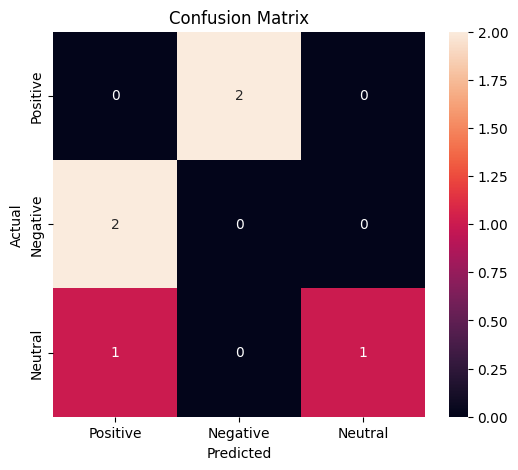

In [12]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Positive", "Negative", "Neutral"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Positive", "Negative", "Neutral"],
    yticklabels=["Positive", "Negative", "Neutral"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [13]:
def predict_sentiment(text):

    if not text or not text.strip():
        return "⚠️ Please enter some text."

    # Preprocess input
    cleaned_text = preprocess_text(text)

    # Convert text into TF-IDF
    text_vector = vectorizer.transform([cleaned_text])

    # Predict sentiment
    prediction = model.predict(text_vector)[0]

    # Get confidence
    probabilities = model.predict_proba(text_vector)[0]
    confidence = max(probabilities) * 100

    # Emoji
    if prediction == "Positive":
        emoji = "😊"
    elif prediction == "Negative":
        emoji = "😞"
    else:
        emoji = "😐"

    return f"{emoji} Sentiment: {prediction}\n📊 Confidence: {confidence:.2f}%"

In [14]:
print(predict_sentiment("I really love this product. It is amazing!"))

print()

print(predict_sentiment("This product is very bad and disappointing."))

print()

print(predict_sentiment("The product is okay."))

😊 Sentiment: Positive
📊 Confidence: 46.58%

😞 Sentiment: Negative
📊 Confidence: 52.73%

😐 Sentiment: Neutral
📊 Confidence: 55.09%


In [15]:
import gradio as gr

app = gr.Interface(
    fn=predict_sentiment,

    inputs=gr.Textbox(
        lines=6,
        placeholder="Type your review or message here...",
        label="Enter Your Text"
    ),

    outputs=gr.Textbox(
        lines=3,
        label="Sentiment Result"
    ),

    title="😊 AI Sentiment Analysis",

    description="Enter any text or review and our AI model will detect whether it is Positive, Negative, or Neutral.",

    examples=[
        ["I absolutely love this product!"],
        ["This service is terrible and disappointing."],
        ["The product is okay and average."]
    ]
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://69debb11eaadb90edf.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [16]:
import gradio as gr

def analyze(text):
    if not text or not text.strip():
        return "⚠️ Please enter some text.", ""

    cleaned_text = preprocess_text(text)
    text_vector = vectorizer.transform([cleaned_text])

    prediction = model.predict(text_vector)[0]
    probabilities = model.predict_proba(text_vector)[0]
    confidence = max(probabilities) * 100

    if prediction == "Positive":
        emoji = "😊"
        message = "Great! The text has a positive sentiment."
    elif prediction == "Negative":
        emoji = "😞"
        message = "The text has a negative sentiment."
    else:
        emoji = "😐"
        message = "The text has a neutral sentiment."

    result = f"{emoji} {prediction}"

    details = f"""
Confidence: {confidence:.2f}%

{message}
"""

    return result, details


custom_css = """
body {
    background: linear-gradient(135deg, #667eea, #764ba2);
}

.gradio-container {
    max-width: 850px !important;
    margin: auto !important;
}

#title {
    text-align: center;
}

textarea {
    font-size: 18px !important;
}

button {
    font-size: 18px !important;
}
"""


with gr.Blocks(css=custom_css, title="AI Sentiment Analysis") as app:

    gr.Markdown(
        """
        # 😊 AI-Based Sentiment Analysis
        ### Analyze the emotional tone of any text
        """
    )

    gr.Markdown(
        """
        Enter a review, comment, feedback, or any sentence.
        Our machine learning model will classify it as
        **Positive, Negative, or Neutral**.
        """
    )

    text_input = gr.Textbox(
        label="📝 Enter Your Text",
        placeholder="Example: I really love this product!",
        lines=6
    )

    analyze_button = gr.Button(
        "🔍 Analyze Sentiment"
    )

    sentiment_output = gr.Textbox(
        label="🎯 Sentiment"
    )

    details_output = gr.Textbox(
        label="📊 Analysis"
    )

    gr.Markdown("### 💡 Try These Examples")

    gr.Examples(
        examples=[
            ["I absolutely love this product!"],
            ["The service was terrible and disappointing."],
            ["The product is okay and average."]
        ],
        inputs=text_input
    )

    analyze_button.click(
        fn=analyze,
        inputs=text_input,
        outputs=[sentiment_output, details_output]
    )

app.launch(share=True)

/tmp/ipykernel_1507/3735948116.py:59: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css, title="AI Sentiment Analysis") as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dbdd40522af7b2be07.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [17]:
# STEP 15: Create a larger sentiment dataset

positive_texts = [
    "I love this product",
    "This product is amazing",
    "Excellent service",
    "I am very happy",
    "The quality is fantastic",
    "This is wonderful",
    "I really enjoyed this",
    "The experience was great",
    "Very good product",
    "I am satisfied",
    "Absolutely fantastic",
    "Really impressed",
    "Highly recommended",
    "The service was excellent",
    "Amazing experience",
    "I would buy this again",
    "Very useful product",
    "I am extremely happy",
    "Great quality",
    "Superb service",
    "The product works perfectly",
    "I love the quality",
    "Very impressive",
    "Outstanding experience",
    "Everything was perfect",
    "I am pleased with the purchase",
    "This is worth the money",
    "The product exceeded my expectations",
    "Fantastic customer service",
    "I had a great experience"
]

negative_texts = [
    "I hate this product",
    "This product is terrible",
    "Worst service ever",
    "I am very disappointed",
    "The quality is very poor",
    "I really disliked this",
    "This is horrible",
    "The service was bad",
    "Very bad product",
    "I am not satisfied",
    "Terrible experience",
    "Very disappointing",
    "I would not recommend this",
    "Poor quality",
    "Waste of money",
    "The product stopped working",
    "I hate the service",
    "Very poor experience",
    "Completely dissatisfied",
    "The product is useless",
    "Bad customer service",
    "I regret buying this",
    "Not worth the money",
    "The quality is awful",
    "Very frustrating",
    "The service was horrible",
    "I am unhappy with the purchase",
    "This product failed",
    "Extremely disappointing",
    "I will never buy this again"
]

neutral_texts = [
    "The product is okay",
    "It is an average product",
    "The service was normal",
    "Nothing special about this",
    "The experience was okay",
    "It is neither good nor bad",
    "Average quality",
    "The product is acceptable",
    "It was fine",
    "The service was ordinary",
    "The product arrived today",
    "I received the product",
    "The service is available",
    "This is a standard product",
    "The package contains the product",
    "The product has two features",
    "The delivery took two days",
    "I used the product today",
    "The product comes in different sizes",
    "The service operates during the day",
    "The product has a simple design",
    "The item is currently available",
    "The package was delivered",
    "The product has basic features",
    "The service is currently active",
    "The product costs 500 rupees",
    "The item is available online",
    "The product comes with instructions",
    "The service starts at 9 AM",
    "The product was delivered yesterday"
]

# Create dataframe
large_texts = positive_texts + negative_texts + neutral_texts

large_labels = (
    ["Positive"] * len(positive_texts) +
    ["Negative"] * len(negative_texts) +
    ["Neutral"] * len(neutral_texts)
)

large_df = pd.DataFrame({
    "text": large_texts,
    "sentiment": large_labels
})

print("Dataset created successfully!")
print("Total records:", len(large_df))
print()

print("Positive:", sum(large_df["sentiment"] == "Positive"))
print("Negative:", sum(large_df["sentiment"] == "Negative"))
print("Neutral :", sum(large_df["sentiment"] == "Neutral"))

large_df.head()

Dataset created successfully!
Total records: 90

Positive: 30
Negative: 30
Neutral : 30


,text,sentiment
0,I love this product,Positive
1,This product is amazing,Positive
2,Excellent service,Positive
3,I am very happy,Positive
4,The quality is fantastic,Positive


In [18]:
# Preprocess the larger dataset

large_df["clean_text"] = large_df["text"].apply(preprocess_text)

X = large_df["clean_text"]
y = large_df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2)
)

X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

# Train model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_vectorized, y_train)

# Prediction
y_pred = model.predict(X_test_vectorized)

accuracy = accuracy_score(y_test, y_pred)

print("New Model Training Completed! ✅")
print("Model Accuracy:", round(accuracy * 100, 2), "%")

New Model Training Completed! ✅
Model Accuracy: 66.67 %


In [19]:
print("Classification Report")
print("=====================")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Classification Report
              precision    recall  f1-score   support

    Negative       0.67      0.67      0.67         6
     Neutral       0.67      1.00      0.80         6
    Positive       0.67      0.33      0.44         6

    accuracy                           0.67        18
   macro avg       0.67      0.67      0.64        18
weighted avg       0.67      0.67      0.64        18



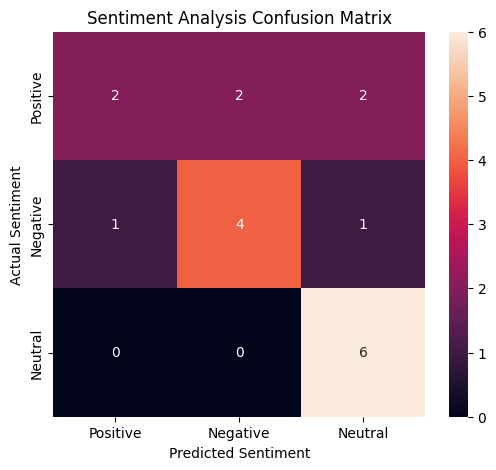

In [20]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Positive", "Negative", "Neutral"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Positive", "Negative", "Neutral"],
    yticklabels=["Positive", "Negative", "Neutral"]
)

plt.title("Sentiment Analysis Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [23]:
def final_prediction(text):

    if not text or not text.strip():
        return {
            "Positive": 0,
            "Negative": 0,
            "Neutral": 0
        }

    cleaned_text = preprocess_text(text)
    text_vector = vectorizer.transform([cleaned_text])

    probabilities = model.predict_proba(text_vector)[0]

    classes = model.classes_

    result = {
        "Positive": 0,
        "Negative": 0,
        "Neutral": 0
    }

    for cls, probability in zip(classes, probabilities):
        result[cls] = round(float(probability), 4)

    return result

In [24]:
test_sentences = [
    "I absolutely love this product!",
    "This is the worst service I have ever experienced.",
    "The product arrived today."
]

for sentence in test_sentences:

    result = final_prediction(sentence)

    print("Text:", sentence)
    print("Positive:", result["Positive"])
    print("Negative:", result["Negative"])
    print("Neutral :", result["Neutral"])
    print("-" * 50)

Text: I absolutely love this product!
Positive: 0.5502
Negative: 0.2099
Neutral : 0.2399
--------------------------------------------------
Text: This is the worst service I have ever experienced.
Positive: 0.2379
Negative: 0.504
Neutral : 0.2581
--------------------------------------------------
Text: The product arrived today.
Positive: 0.2272
Negative: 0.2239
Neutral : 0.5489
--------------------------------------------------


In [25]:
def final_analyze(text):

    if not text or not text.strip():
        return "⚠️ Please enter some text.", ""

    cleaned_text = preprocess_text(text)
    text_vector = vectorizer.transform([cleaned_text])

    prediction = model.predict(text_vector)[0]

    probabilities = model.predict_proba(text_vector)[0]
    classes = model.classes_

    confidence = max(probabilities) * 100

    if prediction == "Positive":
        emoji = "😊"
        message = "The text expresses a positive feeling."
    elif prediction == "Negative":
        emoji = "😞"
        message = "The text expresses a negative feeling."
    else:
        emoji = "😐"
        message = "The text expresses a neutral feeling."

    details = f"""
🎯 Prediction: {prediction}
📊 Confidence: {confidence:.2f}%

😊 Positive: {dict(zip(classes, probabilities)).get("Positive", 0)*100:.2f}%
😞 Negative: {dict(zip(classes, probabilities)).get("Negative", 0)*100:.2f}%
😐 Neutral: {dict(zip(classes, probabilities)).get("Neutral", 0)*100:.2f}%

💡 {message}
"""

    return f"{emoji} {prediction}", details

In [26]:
with gr.Blocks(
    title="AI Sentiment Analysis"
) as final_app:

    gr.Markdown(
        """
        # 😊 AI-Based Sentiment Analysis
        ### Text-Based Sentiment Detection System

        Analyze any text and identify whether it is
        **Positive, Negative, or Neutral**.
        """
    )

    text_input = gr.Textbox(
        label="📝 Enter Your Text",
        placeholder="Type your review or message here...",
        lines=6
    )

    analyze_btn = gr.Button(
        "🔍 Analyze Sentiment"
    )

    result = gr.Textbox(
        label="🎯 Result"
    )

    details = gr.Textbox(
        label="📊 Detailed Analysis",
        lines=8
    )

    gr.Examples(
        examples=[
            ["I really love this product!"],
            ["This service is terrible."],
            ["The product arrived today."]
        ],
        inputs=text_input
    )

    analyze_btn.click(
        fn=final_analyze,
        inputs=text_input,
        outputs=[result, details]
    )

final_app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cc4cf6f8669801d5ac.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [27]:
with gr.Blocks(
    title="AI Sentiment Analysis"
) as final_app:

    gr.Markdown(
        """
        # 😊 AI-Based Sentiment Analysis
        ### Text-Based Sentiment Detection System

        Analyze any text and identify whether it is
        **Positive, Negative, or Neutral**.
        """
    )

    text_input = gr.Textbox(
        label="📝 Enter Your Text",
        placeholder="Type your review or message here...",
        lines=6
    )

    analyze_btn = gr.Button(
        "🔍 Analyze Sentiment"
    )

    result = gr.Textbox(
        label="🎯 Result"
    )

    details = gr.Textbox(
        label="📊 Detailed Analysis",
        lines=8
    )

    gr.Examples(
        examples=[
            ["I really love this product!"],
            ["This service is terrible."],
            ["The product arrived today."]
        ],
        inputs=text_input
    )

    analyze_btn.click(
        fn=final_analyze,
        inputs=text_input,
        outputs=[result, details]
    )

final_app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9795a59622e149bdd2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [28]:
import joblib

# Save the trained ML model
joblib.dump(model, "sentiment_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model saved successfully! ✅")
print("sentiment_model.pkl")
print("tfidf_vectorizer.pkl")

Model saved successfully! ✅
sentiment_model.pkl
tfidf_vectorizer.pkl


In [29]:
import os

print("Saved Files:")
print("----------------")

for file in os.listdir():
    if file.endswith(".pkl"):
        print("✅", file)

Saved Files:
----------------
✅ sentiment_model.pkl
✅ tfidf_vectorizer.pkl


In [32]:
from google.colab import files

files.download("sentiment_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
import os

print("Saved Files:")
print("----------------")

for file in os.listdir():
    if file.endswith(".pkl"):
        print("✅", file)

Saved Files:
----------------
✅ sentiment_model.pkl
✅ tfidf_vectorizer.pkl


In [34]:
from google.colab import files

files.download("sentiment_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
final_app.launch(share=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9795a59622e149bdd2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [37]:
final_app.launch(share=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9795a59622e149bdd2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [38]:
print("=" * 50)
print("AI-BASED TEXT SENTIMENT ANALYSIS")
print("=" * 50)

print("Model              : Logistic Regression")
print("Feature Extraction : TF-IDF")
print("Sentiments          : Positive / Negative / Neutral")
print("Application         : Gradio")
print("Platform            : Google Colab")

print("=" * 50)
print("PROJECT COMPLETED SUCCESSFULLY! ✅")
print("=" * 50)

AI-BASED TEXT SENTIMENT ANALYSIS
Model              : Logistic Regression
Feature Extraction : TF-IDF
Sentiments          : Positive / Negative / Neutral
Application         : Gradio
Platform            : Google Colab
PROJECT COMPLETED SUCCESSFULLY! ✅


In [39]:
!pip install -q --upgrade gradio

In [40]:
final_app.launch(share=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9795a59622e149bdd2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [41]:
import gradio as gr

def test_app(text):
    return "You entered: " + text

demo = gr.Interface(
    fn=test_app,
    inputs="text",
    outputs="text",
    title="Test Application"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://527c4a17866f9a349f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
